# Adventage Actor-Critic Algorithm (A2C)
Policy-based method, based on 2 neural networks - one to model "Actor" (policy network) and second one to model "Critic" (value network). As policy-based methods are based on the probabilities, the policy network can also handle continious action spaces, which is not a case for deep Q-learnig, where every node represents one action. Policy networks can output the parameters of any distribuiotion.  Idea behind this method: Instead of coming up with loss directly, let's find its gradient -> "Policy Gradient". It also uses batch version of training. 

To calculate expected value we can use sampling (like in Monte Carlo), however this method performas multiple rollouts, then take the average. Now, the most imporant part - the strategy is based on Global Network and Worker networks, wchich are responsible for doing the rollouts. Every n steps, each owrker send its gradients back to master (Global Network) and then master updates its weights. So it results in the fact that master network has always most updated version the of policy. 

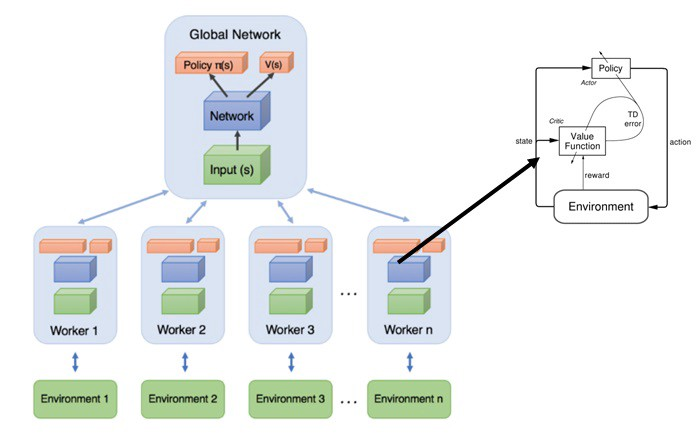


A2C in original version used to take n (in original OpenAI setting: n=5) enviroments and runs each of them in paraller. Each of them returns (s, a, r, s') and this data in used to update master network. The paraller processes are done synchronously (main difference in respect to A3C). 

Advetages:
- no need to implement epsilon-greedy algorithm like in Q-learning
- more control over randomness
- regularization through entropy

Paper: https://arxiv.org/abs/1602.01783

Implementation: - using stable baseline 3 that are based on OpenAI Gym Baselines algorithms (https://github.com/DLR-RM/stable-baselines3/tree/master/stable_baselines3/a2c)

In [1]:
# !pip3 install torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu116

In [2]:
import os
import pprint
import random
import warnings
import numpy as np

from gym import Env
from Environment.simulator import *
from Environment.my_utils import *
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.evaluation import evaluate_policy

import gym
from stable_baselines3.common.vec_env import DummyVecEnv, VecCheckNan
from stable_baselines3 import A2C
from stable_baselines3.common.env_util import make_vec_env

os.environ['CUDA_VISIBLE_DEVICES'] = '-1'


warnings.filterwarnings("ignore")

Prepare the enviroment

In [3]:
# SIM PARAMETERS
SLA = 3
VM_TYPE1 = 7
VM_TYPE2 = 3
VM_TYPE3 = 1
SCENARIO = 'train'
PENALTY = 200
STEPS = 100
ALPHA = 0.5
BETA = 0.5

env = Sim(sla = SLA,
          vm_1 = VM_TYPE1,
          vm_2 = VM_TYPE2,
          vm_3 = VM_TYPE3,
          penalty = PENALTY,
          steps = STEPS,
          scenario = SCENARIO,
          alpha = ALPHA,
          beta = BETA)

Train the model

In [4]:
model = A2C('MlpPolicy', env, verbose = 1, learning_rate=0.003, gamma=0.99)
model.learn(total_timesteps=1000)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 100      |
|    ep_rew_mean        | 47.1     |
| time/                 |          |
|    fps                | 0        |
|    iterations         | 100      |
|    time_elapsed       | 1654     |
|    total_timesteps    | 500      |
| train/                |          |
|    entropy_loss       | -0.0108  |
|    explained_variance | 0        |
|    learning_rate      | 0.003    |
|    n_updates          | 99       |
|    policy_loss        | 0.00036  |
|    value_loss         | 0.107    |
------------------------------------
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 100      |
|    ep_rew_mean        | 48.8     |
| time/                 |          |
|    fps                | 0        |
|    iterations         | 200      |
|    time_elapsed 

In [5]:
model_path = os.path.join('Training', 'Saved Models', 'best_model_A2C')
model.save(model_path)

In [6]:
# model = A2C.load(model_path, env=env)

Evaluate the policy

In [7]:
# evaluate_policy(model, env, n_eval_episodes=10, render=True)

Test the model

info {'Quality of Service': 5.396627210925667, 'Current cost': 470, 'Semi-stochastic queue': [4, 5, 6, 6, 7, 9, 10, 10, 12, 10], 'Timer': 1.8530092239379883, 'VM type I': 7, 'VM type II': 3, 'VM type III': 3}


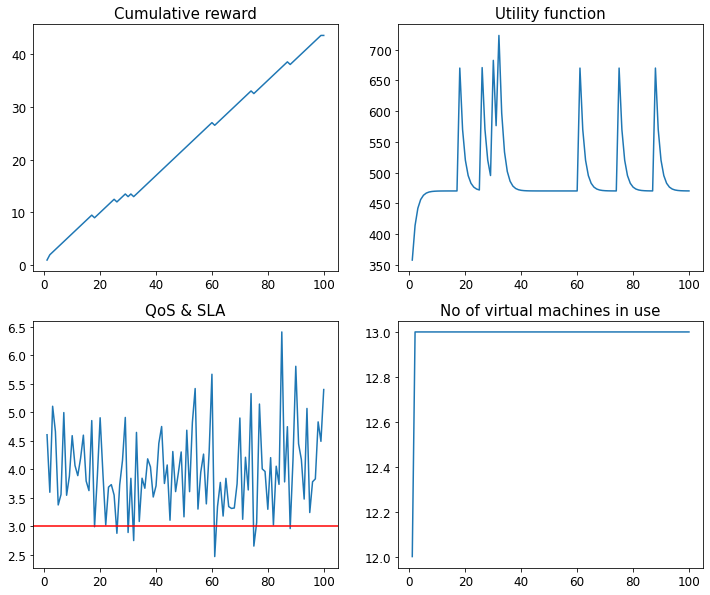

Cumulative reward at the end of the test:  43.5
Avg cost minus penalty per step:  495.75
Avg quality of service:  3.99
Avg no of virtual machines:  12.99


In [8]:
SCENARIO = 'test_scenario_1'
test_model_SB(model, SLA, VM_TYPE1, VM_TYPE2, VM_TYPE3, STEPS, SCENARIO, PENALTY, ALPHA, BETA)

info {'Quality of Service': 4.322008547558999, 'Current cost': 470, 'Semi-stochastic queue': [7, 10, 7, 4, 3, 3, 6, 5, 8, 10], 'Timer': 2.313739061355591, 'VM type I': 7, 'VM type II': 3, 'VM type III': 3}


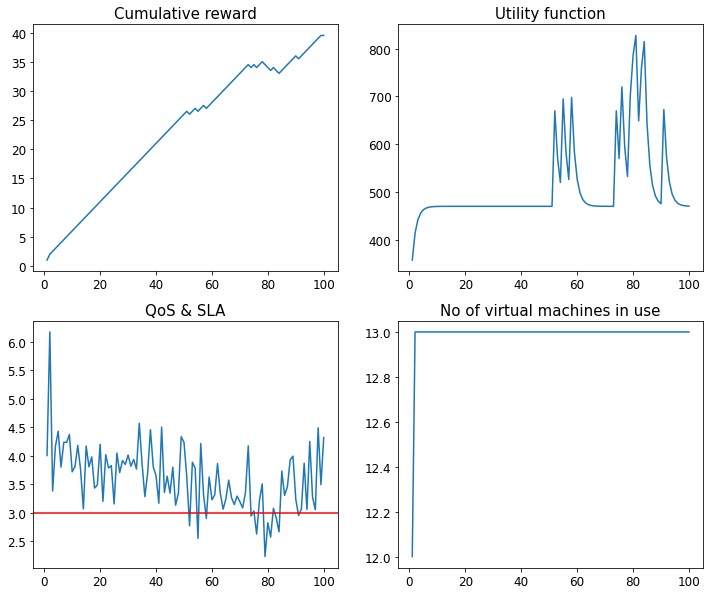

Cumulative reward at the end of the test:  39.5
Avg cost minus penalty per step:  511.75
Avg quality of service:  3.61
Avg no of virtual machines:  12.99


In [9]:
SCENARIO = 'test_scenario_2'
test_model_SB(model, SLA, VM_TYPE1, VM_TYPE2, VM_TYPE3, STEPS, SCENARIO, PENALTY, ALPHA, BETA)

info {'Quality of Service': 3.320449382412679, 'Current cost': 470, 'Semi-stochastic queue': [10, 10, 8, 8, 6, 5, 4, 5, 4, 3], 'Timer': 3.0116405487060547, 'VM type I': 7, 'VM type II': 3, 'VM type III': 3}


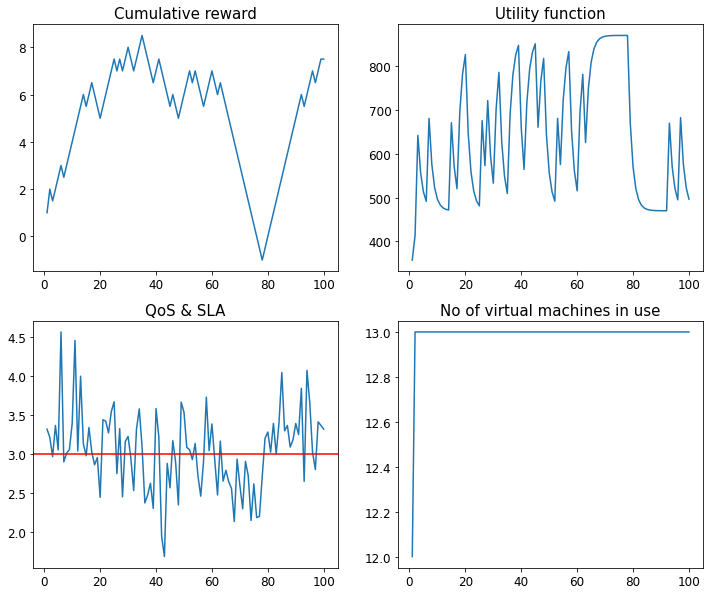

Cumulative reward at the end of the test:  7.5
Avg cost minus penalty per step:  639.48
Avg quality of service:  3.04
Avg no of virtual machines:  12.99


In [10]:
SCENARIO = 'test_scenario_3'
test_model_SB(model, SLA, VM_TYPE1, VM_TYPE2, VM_TYPE3, STEPS, SCENARIO, PENALTY, ALPHA, BETA)